In [9]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
import pandas as  pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16LCD
import seaborn as sns

In [6]:
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe', 'data/colors/munsell_colors/munsell_manifest.csv')
data = analyzer.chain_loader.get_all_available_embeddings()
lm_matrix_all = data['lm_pooled']
vision_matrix_all = data['vl_pooled']
color_meta_all = data['metadata']
lm_matrix_all.shape, vision_matrix_all.shape

((1755, 3584), (1755, 3584))

In [7]:
keys = sorted(color_meta_all.keys(), key=lambda k: int(k))

colors_xyY_all = np.array([
    [color_meta_all[k]['xyY']['x'],
    color_meta_all[k]['xyY']['y'],
    color_meta_all[k]['xyY']['Y']]
    for k in keys
    ], dtype=float)

print(colors_xyY_all.shape) 

(1755, 3)


Starting color space calibration analysis...

LM layer: Converted to CAM16-LCD shape: (1755, 3)

Train size: 351, Test size: 1404
  Ridge: CV R² = 0.9985 ± 0.0003


/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.903e+02, tolerance: 2.740e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.345e+02, tolerance: 2.606e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, c

  Lasso: CV R² = 0.9955 ± 0.0005


/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.621e+02, tolerance: 2.744e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.153e+02, tolerance: 2.831e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, c

  ElasticNet: CV R² = 0.9964 ± 0.0004
  Best model: Ridge

LM layer performance:
  Overall R² = 0.9982, RMSE = 1.8224, MAE = 0.9801
  R² per dimension: L=0.999, a=0.997, b=0.999

LM layer distance correlations:
  Pearson(dist_true, dist_pred)  = 0.9970 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9974 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5191 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.5626 (p = 0.00e+00)
  Pearson(dist_emb, dist_pred)   = 0.5209 (p = 0.00e+00)
  Spearman(dist_emb, dist_pred)  = 0.5627 (p = 0.00e+00)
  k-NN preservation (k=5): 0.763
  k-NN preservation (k=10): 0.812
  k-NN preservation (k=20): 0.845
  Isotropy score: 0.990


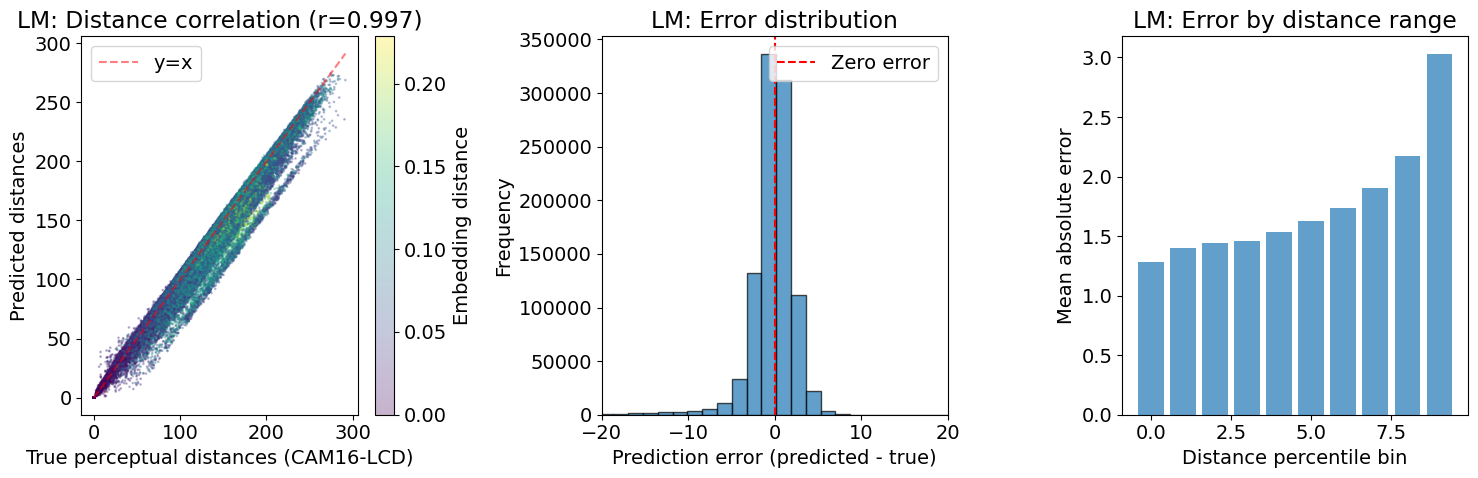

Size of singular values: (3,)

LM layer transformation analysis:
  Matrix W shape: (3, 3584), Bias b shape: (3,)
  Effective rank: 3/3
  Condition number: 2.13
  Top 3 singular values: [ 11.7731      8.198357    5.5266566]

Vision layer: Converted to CAM16-LCD shape: (1755, 3)

Train size: 351, Test size: 1404
  Ridge: CV R² = 0.9963 ± 0.0006


/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.956e+02, tolerance: 8.458e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.833e+02, tolerance: 8.588e+01
  model = cd_fast.enet_coordinate_descent(


  Lasso: CV R² = 0.9793 ± 0.0030


/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.900e+02, tolerance: 2.831e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.603e+02, tolerance: 2.744e+01
  model = cd_fast.enet_coordinate_descent(
/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, c

  ElasticNet: CV R² = 0.9713 ± 0.0039
  Best model: Ridge

Vision layer performance:
  Overall R² = 0.9968, RMSE = 2.4315, MAE = 1.6452
  R² per dimension: L=0.997, a=0.996, b=0.998

Vision layer distance correlations:
  Pearson(dist_true, dist_pred)  = 0.9952 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9955 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5299 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.6094 (p = 0.00e+00)
  Pearson(dist_emb, dist_pred)   = 0.5263 (p = 0.00e+00)
  Spearman(dist_emb, dist_pred)  = 0.6067 (p = 0.00e+00)
  k-NN preservation (k=5): 0.701
  k-NN preservation (k=10): 0.755
  k-NN preservation (k=20): 0.784
  Isotropy score: 0.986


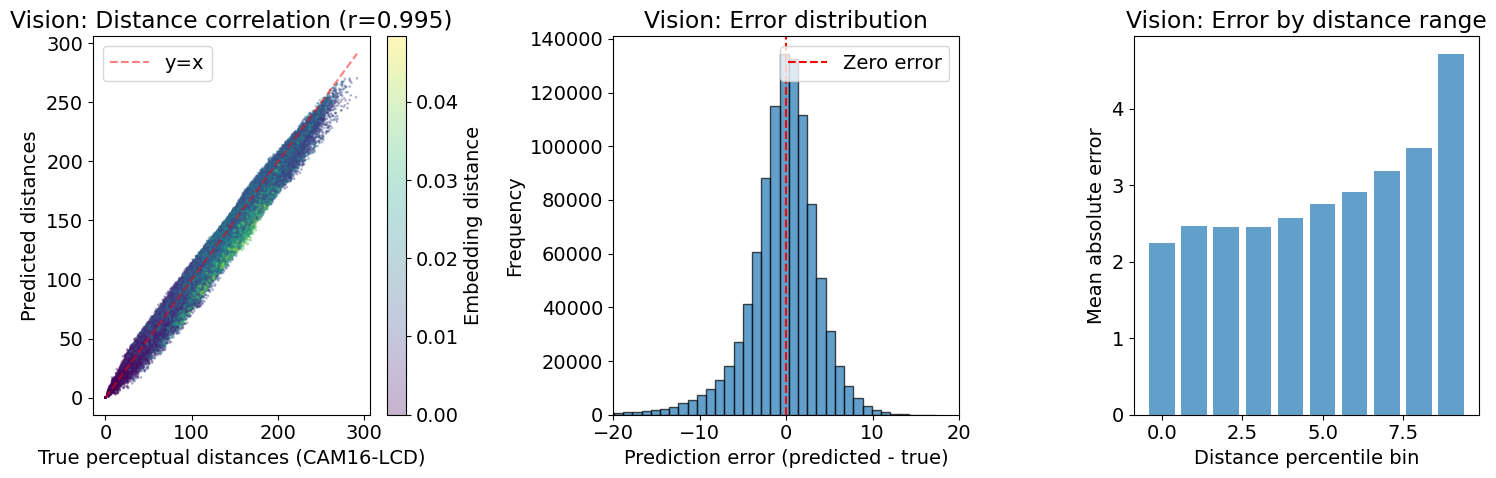

Size of singular values: (3,)

Vision layer transformation analysis:
  Matrix W shape: (3, 3584), Bias b shape: (3,)
  Effective rank: 3/3
  Condition number: 2.49
  Top 3 singular values: [ 72.00576   48.116077  28.9097  ]

Cross-layer comparison:
  Correlation between LM and Vision predictions:
    Pearson = 0.9997
    Spearman = 0.9996
  Distance preservation between layers: 0.9966


In [ ]:
def linear_color_mapping(embeddings, colors_xyY, layer_name="LM", alpha=1.0):
    # Преобразуем xyY → CAM16-LCD (векторизованно)
    colors_cam = np.array([XYZ_to_CAM16LCD(xyY_to_XYZ(c)) for c in colors_xyY])
    print(f"\n{'='*60}")
    print(f"{layer_name} layer: Converted to CAM16-LCD shape: {colors_cam.shape}")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, colors_cam, test_size=0.8, random_state=42
    )

    print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

    # Сравнение разных моделей регрессии
    models = {
        'Ridge': Ridge(alpha=alpha),
        'Lasso': Lasso(alpha=alpha/10, max_iter=2000),
        'ElasticNet': ElasticNet(alpha=alpha/10, l1_ratio=0.5, max_iter=2000)
    }
    
    best_model = None
    best_score = -np.inf
    
    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                   scoring='r2', n_jobs=-1)
        mean_cv_score = np.mean(cv_scores)
        print(f"  {name}: CV R² = {mean_cv_score:.4f} ± {np.std(cv_scores):.4f}")
        
        if mean_cv_score > best_score:
            best_score = mean_cv_score
            best_model = model
            best_model_name = name
    
    # Обучаем лучшую модель
    reg = best_model
    reg.fit(X_train, y_train)
    print(f"  Best model: {best_model_name}")
    
    y_pred_test = reg.predict(X_test)
    y_pred_all = reg.predict(embeddings)
    
    # Расширенная оценка точности
    r2 = r2_score(y_test, y_pred_test, multioutput='variance_weighted')
    r2_per_dim = r2_score(y_test, y_pred_test, multioutput='raw_values')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    
    print(f"\n{layer_name} layer performance:")
    print(f"  Overall R² = {r2:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")
    print(f"  R² per dimension: L={r2_per_dim[0]:.3f}, a={r2_per_dim[1]:.3f}, b={r2_per_dim[2]:.3f}")

    # Вычисляем попарные расстояния (используем pdist для эффективности)
    # pdist возвращает только верхний треугольник матрицы расстояний
    v_emb = pdist(X_test, metric='cosine')
    v_true = pdist(y_test, metric='euclidean')
    v_pred = pdist(y_pred_test, metric='euclidean')
    
    # Дополнительные метрики расстояний
    # v_true_deltaE = pdist(colors_cam, metric='euclidean')  # ΔE в CAM16-LCD
    
    # Корреляции между расстояниями
    correlations = {}
    
    # True vs Predicted
    pearson_r, pearson_p = pearsonr(v_true, v_pred)
    spearman_r, spearman_p = spearmanr(v_true, v_pred)
    correlations['true_pred'] = {
        'pearson': (pearson_r, pearson_p),
        'spearman': (spearman_r, spearman_p)
    }
    
    # Embedding vs True
    emb_true_pr, emb_true_pp = pearsonr(v_emb, v_true)
    emb_true_sr, emb_true_sp = spearmanr(v_emb, v_true)
    correlations['emb_true'] = {
        'pearson': (emb_true_pr, emb_true_pp),
        'spearman': (emb_true_sr, emb_true_sp)
    }
    
    # Embedding vs Predicted
    emb_pred_pr, emb_pred_pp = pearsonr(v_emb, v_pred)
    emb_pred_sr, emb_pred_sp = spearmanr(v_emb, v_pred)
    correlations['emb_pred'] = {
        'pearson': (emb_pred_pr, emb_pred_pp),
        'spearman': (emb_pred_sr, emb_pred_sp)
    }
    
    print(f"\n{layer_name} layer distance correlations:")
    print(f"  Pearson(dist_true, dist_pred)  = {pearson_r:.4f} (p = {pearson_p:.2e})")
    print(f"  Spearman(dist_true, dist_pred) = {spearman_r:.4f} (p = {spearman_p:.2e})")
    print(f"  Pearson(dist_emb, dist_true)   = {emb_true_pr:.4f} (p = {emb_true_pp:.2e})")
    print(f"  Spearman(dist_emb, dist_true)  = {emb_true_sr:.4f} (p = {emb_true_sp:.2e})")
    print(f"  Pearson(dist_emb, dist_pred)   = {emb_pred_pr:.4f} (p = {emb_pred_pp:.2e})")
    print(f"  Spearman(dist_emb, dist_pred)  = {emb_pred_sr:.4f} (p = {emb_pred_sp:.2e})")
    
    # Анализ сохранения локальной структуры (k-NN consistency)
    k_neighbors = [5, 10, 20]
    for k in k_neighbors:
        knn_accuracy = compute_knn_preservation(embeddings, colors_cam, y_pred_all, k)
        print(f"  k-NN preservation (k={k}): {knn_accuracy:.3f}")
    
    # Анализ изотропности (проверка искажений в разных направлениях)
    isotropy_score = analyze_isotropy(v_true, v_pred)
    print(f"  Isotropy score: {isotropy_score:.3f}")
    
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Scatter plot расстояний
    ax1 = axes[0]
    scatter = ax1.scatter(v_true, v_pred, s=1, alpha=0.3, c=v_emb, cmap='viridis')
    ax1.plot([0, max(v_true)], [0, max(v_true)], 'r--', alpha=0.5, label='y=x')
    ax1.set_xlabel('True perceptual distances (CAM16-LCD)')
    ax1.set_ylabel('Predicted distances')
    ax1.set_title(f'{layer_name}: Distance correlation (r={pearson_r:.3f})')
    ax1.legend()
    plt.colorbar(scatter, ax=ax1, label='Embedding distance')
    
    # 2. Распределение ошибок
    ax2 = axes[1]
    errors = v_pred - v_true
    ax2.hist(errors, bins=50, alpha=0.7, edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', label='Zero error')
    ax2.set_xlabel('Prediction error (predicted - true)')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'{layer_name}: Error distribution')
    ax2.set_xlim(-20, 20)
    ax2.legend()
    
    # 3. Heatmap ошибок по расстояниям
    ax3 = axes[2]
    # Биннинг для анализа ошибок
    bins = np.percentile(v_true, np.linspace(0, 100, 11))
    bin_indices = np.digitize(v_true, bins) - 1
    mean_errors = [np.mean(np.abs(errors[bin_indices == i])) 
                   for i in range(len(bins)-1)]
    
    ax3.bar(range(len(mean_errors)), mean_errors, alpha=0.7)
    ax3.set_xlabel('Distance percentile bin')
    ax3.set_ylabel('Mean absolute error')
    ax3.set_title(f'{layer_name}: Error by distance range')
    
    plt.tight_layout()
    plt.show()
    
    # Анализ матрицы преобразования
    W = reg.coef_
    b = reg.intercept_
    
    # Singular value decomposition для анализа ранга
    U, s, Vt = np.linalg.svd(W)
    print(f'Size of singular values: {s.shape}')
    effective_rank = np.sum(s > 0.01 * s[0])  # Эффективный ранг
    condition_number = s[0] / s[-1] if s[-1] > 0 else np.inf
    
    print(f"\n{layer_name} layer transformation analysis:")
    print(f"  Matrix W shape: {W.shape}, Bias b shape: {b.shape}")
    print(f"  Effective rank: {effective_rank}/{min(W.shape)}")
    print(f"  Condition number: {condition_number:.2f}")
    print(f"  Top 3 singular values: {s[:3]}")
    
    return {
        'predictions': y_pred_all,
        'model': reg,
        'W': W,
        'b': b,
        'correlations': correlations,
        'metrics': {
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'isotropy': isotropy_score
        }
    }

def compute_knn_preservation(embeddings, true_colors, pred_colors, k=10):
    """Проверяет, сохраняются ли k ближайших соседей после преобразования"""
    from sklearn.neighbors import NearestNeighbors
    
    nn_emb = NearestNeighbors(n_neighbors=k+1, metric='cosine')
    nn_true = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    nn_pred = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    
    nn_emb.fit(embeddings)
    nn_true.fit(true_colors)
    nn_pred.fit(pred_colors)
    
    preservation_scores = []
    for i in range(len(embeddings)):
        # Находим k ближайших соседей (исключая сам элемент)
        emb_neighbors = set(nn_emb.kneighbors([embeddings[i]], return_distance=False)[0][1:])
        true_neighbors = set(nn_true.kneighbors([true_colors[i]], return_distance=False)[0][1:])
        pred_neighbors = set(nn_pred.kneighbors([pred_colors[i]], return_distance=False)[0][1:])
        
        # Jaccard similarity между true и predicted
        intersection = len(true_neighbors & pred_neighbors)
        union = len(true_neighbors | pred_neighbors)
        preservation_scores.append(intersection / union if union > 0 else 0)
    
    return np.mean(preservation_scores)

def analyze_isotropy(true_distances, pred_distances):
    """Анализирует изотропность преобразования"""
    # Разбиваем расстояния на квантили и проверяем дисперсию ошибок
    n_bins = 10
    bins = np.percentile(true_distances, np.linspace(0, 100, n_bins+1))
    bin_indices = np.digitize(true_distances, bins) - 1
    
    errors_by_bin = []
    for i in range(n_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            rel_errors = np.abs((pred_distances[mask] - true_distances[mask]) / 
                              (true_distances[mask] + 1e-6))
            errors_by_bin.append(np.std(rel_errors))
    
    # Низкая дисперсия дисперсий означает изотропность
    isotropy = 1.0 / (1.0 + np.std(errors_by_bin))
    return isotropy

# Запуск анализа
print("Starting color space calibration analysis...")

# LM layer
results_lm = linear_color_mapping(lm_matrix_all, colors_xyY_all, layer_name="LM", alpha=1.0)

# Vision layer  
results_vl = linear_color_mapping(vision_matrix_all, colors_xyY_all, layer_name="Vision", alpha=1.0)

# Сравнение между слоями
print(f"\n{'='*60}")
print("Cross-layer comparison:")

# Корреляция предсказаний
pred_corr_pearson = pearsonr(results_lm['predictions'].flatten(), 
                             results_vl['predictions'].flatten())[0]
pred_corr_spearman = spearmanr(results_lm['predictions'].flatten(), 
                               results_vl['predictions'].flatten())[0]

print(f"  Correlation between LM and Vision predictions:")
print(f"    Pearson = {pred_corr_pearson:.4f}")
print(f"    Spearman = {pred_corr_spearman:.4f}")

# Согласованность расстояний между слоями
v_pred_lm = pdist(results_lm['predictions'], metric='euclidean')
v_pred_vl = pdist(results_vl['predictions'], metric='euclidean')
dist_corr = pearsonr(v_pred_lm, v_pred_vl)[0]
print(f"  Distance preservation between layers: {dist_corr:.4f}")

In [10]:
colors_cam = np.array([XYZ_to_CAM16LCD(xyY_to_XYZ(c)) for c in colors_xyY_all])

In [12]:
from utils.analyze.metric_learner import run_metric_learning_example

In [14]:
run_metric_learning_example(embeddings=data['lm_pooled'], cam_distances=colors_cam, layer_name="LM")


METRIC LEARNING: LM LAYER


IndexError: index 727 is out of bounds for axis 1 with size 3